<a href="https://colab.research.google.com/github/navadeepsaran/AIML_project_and_labs/blob/main/AIML_Module_2_Lab_3_Manifold_Learning_Methodsnav.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Module 2: Appreciating, Interpreting and Visualizing Data
## Lab 3: Manifold Learning Methods

---



Today, we will be focussing on non-linear dimensionality reduction methods or **Manifold learning** methods.

So a manifold is any space that is locally Euclidean. For example, the Earth is round but it looks flat to us. The Earth is a manifold: locally it is flat, but globally we know it is a sphere. Then, manifold learning performs dimensionality reduction by representing data as low-dimensional manifolds embedded in a higher-dimensional space.

We often suspect that high-dim may actually lie on or near a low-dim manifold (often much lower!) and it would be useful if we could reparametrize the data in terms of this manifold, yielding a low-dim embedding BUT - we typically don’t know the form of this manifold.

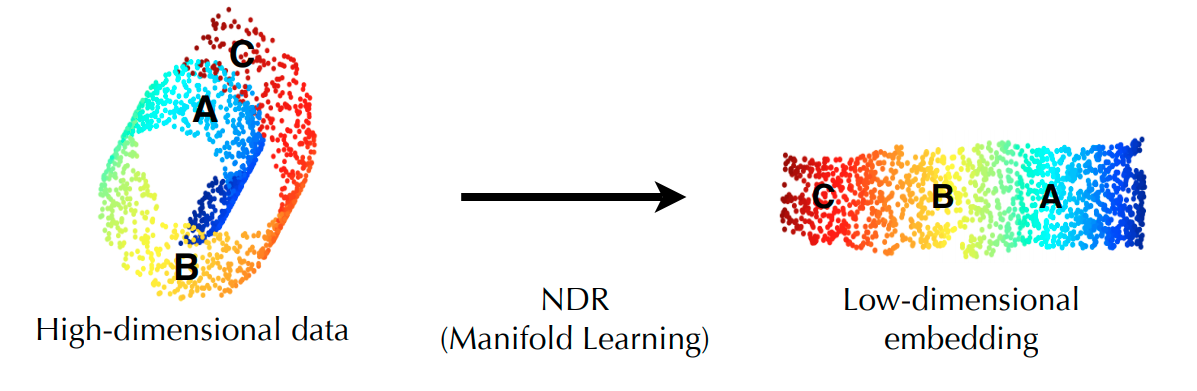

**What is a Manifold?**

**Analogy:**

Imagine you’re an ant walking on a globe. To you, the surface seems flat, but in reality, it’s curved. The globe is a manifold: locally flat, but globally curved. Manifold learning tries to "unroll" this globe into a flat map, preserving the true distances as much as possible.

**Why do we care?**

High-dimensional data (e.g., images, text, or sensor data) often lies on a lower-dimensional "surface" (manifold) embedded in a high-dimensional space.
Manifold learning helps us discover and visualize this hidden structure.

## ISOMAP

---

Isomap stands for **ISOmetric feature MAPping**. Isomap is a non-linear dimensionality reduction method based on the spectral theory which tries to preserve the geodesic distances in the lower dimension.

#### But what are Geodesic Distances?



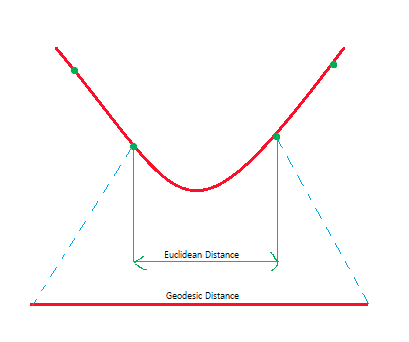

**Euclidean vs. Geodesic Distances:**

- Euclidean distance: Straight-line distance between two points.
- Geodesic distance: Shortest path along the surface of the manifold.

**Example:**

On Earth, the Euclidean distance between two cities is a straight line through the planet (useless!). The geodesic distance is the great-circle distance (what GPS uses).

The next question should be:

*How can we compute geodesics without knowing the manifold?* .......
ANSWER: So we build an adjacency graph and approximate geodesic distances by shortest-paths through the graph.


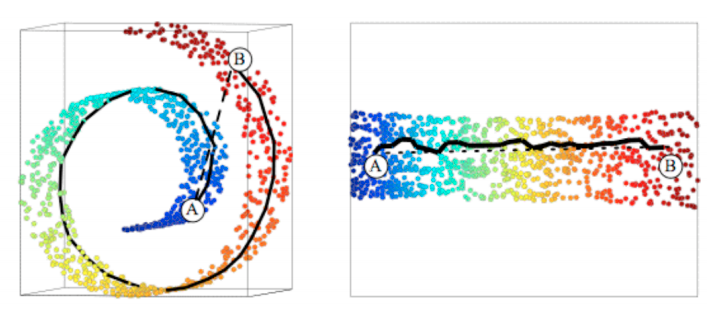

#### 3 steps for ISOMAP:

1. Build the adjacency graph over the points using a Neighbourhood selection method (let's say k nearest neighbours)
2. Compute approximate geodesics: Weight graph edges by inter-point distances and then apply Dijkstra’s all-pairs shortest-paths algorithm.
3. Take the top d eigenvectors of the Gram matrix.


**What is Isomap?**

Isomap is like a GPS for data points. Instead of using straight-line (Euclidean) distances, it uses "road distances" (geodesic distances) to map the data.
It’s useful when data points are connected in a non-linear way (e.g., a curved surface).

**Example:**

Think of a piece of paper rolled into a tube. If you measure distances along the paper (not through the air), you’re using geodesic distances. Isomap tries to "flatten" the tube while keeping these distances accurate.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn import datasets

First let us simulate a dataset with the points lying on a manifold which we would want our Isomap to be able to capture.

We will be using the make_s_curve() function in the sklearn.datasets module to make the manifold using 1000 data points

In [ ]:
n_points = 1000
X, color = datasets.make_s_curve(n_points, random_state=0)

**Why use the S-curve?**

The S-curve is a classic example of a 2D manifold embedded in 3D space.
It’s non-linear, so linear methods like PCA struggle to "unroll" it, but Isomap can.

In [ ]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=color, cmap=plt.cm.Dark2)
ax.view_init(4, -72)

**Observation:**

- The S-curve is a 2D surface (a sheet of paper) bent in 3D space.
- Isomap will try to "unbend" this surface into a flat 2D plane.

Note that all the points appear to be a lying on a curved 2d plane in this 3d dataset. Now we will be coding the Isomap algorithm to perform this manifold learning.


---

### Step 1a: First lets compute the distance matrix (pairwise Euclidean distances) from the data


In [ ]:
def dist(a, b):
  '''Computes Euclidean distance between 2 points'''
  return np.sqrt(sum((a - b) ** 2))

distances = np.array([[dist(p1, p2) for p2 in X] for p1 in X])

# For N points in the dataset, this matrix should be of the dimension NxN.
# Our dataset had 1000 points, so we expect the dimensions of this matrix to be 1000x1000
print(distances.shape)

(1000, 1000)


**What’s happening?**

- We compute the Euclidean distance between every pair of points.
- This gives us an N x N matrix, where N is the number of points (1000 here).

### Step 1b: Let us keep only k nearest neighbors for each point in the distance matrix.

In [ ]:
# Lets keep only the 10 nearest neighbors, others set to 0 (= unreachable)

n_neighbors = 10
neighbors = np.zeros(distances.shape)

sort_distances = np.argsort(distances, axis=1)[:, 1:n_neighbors+1]
for k,i in enumerate(sort_distances):
    neighbors[k,i] = distances[k,i]

In [ ]:
neighbors.shape

(1000, 1000)

**Adjacency Graph**

**What’s happening?**

- We connect each point to its k nearest neighbors, creating a network (graph).
- This graph approximates the true shape of the manifold.

**Analogy:**

Imagine you’re in a maze. You can only see nearby walls (neighbors). By connecting to your neighbors, you can find the shortest path to any other point in the maze.



---

### Step 2: Weight graph edges by inter-point distances and then apply Dijkstra’s all-pairs shortest-paths algorithm.

We will be using the graph_shortest_path() function in the sklearn.utils.graph module.

The function takes an array of positive distances as the parameter. It then performs a shortest-path graph search on the graph and returns a matrix G (shape = N,N), where, G(i,j) gives the shortest distance from point i to point j along the graph.


In [ ]:
from scipy.sparse.csgraph import shortest_path

graph = shortest_path(neighbors, directed=False)

**Dijkstra’s Algorithm**

**What’s happening?**

- We calculate the shortest path between every pair of points using Dijkstra’s algorithm.
- This gives us the "true" distances along the manifold, not just straight-line distances.

**Example:**

If you’re driving from Delhi to Mumbai, the road distance (geodesic) is longer than the straight-line (Euclidean) distance on a map. Isomap uses the road distance.



---
### Step 3: Take the top d eigenvectors of the Gram matrix.


So let us first compute the gram matrix. If we have a matrix **graph**, then its Gram matrix is **graph**.T * **graph**





In [ ]:
gram = (graph ** 2)

We will now be computing the eigenvectors for this matrix, so lets first center the data points.

In [ ]:
n_samples = gram.shape[0]

# Mean for each row/column
meanrows = np.sum(gram, axis=0) / n_samples
meancols = (np.sum(gram, axis=1)/n_samples)[:, np.newaxis]

# NUMPY TRICKS: np.newaxis is used to increase the dimension of the existing array by one more dimension. So a (1000,) matrix becomes a (1000,1) matrix.

# Mean across all rows (entire matrix)
meanall = meanrows.sum() / n_samples

gram -= meanrows
gram -= meancols
gram += meanall

Computing eigenvectors

In [ ]:
# Using the np.linalg.eig() to compute eigenvectors and eigenvalues for the matrix
eig_val_cov, eig_vec_cov = np.linalg.eig(gram)

# We will be sorting the eigenvalues and to preserve the corresponding eigenvectors, let us make a list of (eigenvalue, eigenvector) tuples
eig_pairs = [(np.abs(eig_val_cov[i]), eig_vec_cov[:, i]) for i in range(len(eig_val_cov))]

# We want to reduce the dimensionality to **n_components** dimensions, therefore we will be first taking the top **n_components** eigenvectors (sorted in descending by eigenvalues)
eig_pairs.sort(key=lambda x: x[0], reverse=True)
eig_pa_chebyshevirs = np.array(eig_pairs, dtype=object)

# Transforming the matrix (dimensionality reduction)
n_components = 2

reduced_matrix = np.zeros((n_components, gram.shape[1]))
for i in range(n_components):
  reduced_matrix[i,:] = eig_pa_chebyshevirs[i,1]
reduced_matrix = reduced_matrix.T

**Eigenvectors and the Gram Matrix**

**What’s happening?**

- We compute the Gram matrix (a matrix of inner products) and find its top eigenvectors.
- These eigenvectors give us the coordinates in the lower-dimensional space.

**Analogy:**

Think of the Gram matrix as a "distortion detector." The top eigenvectors help us "unfold" the manifold into a flat space.



---

## Plotting the resultant reduced_matrix


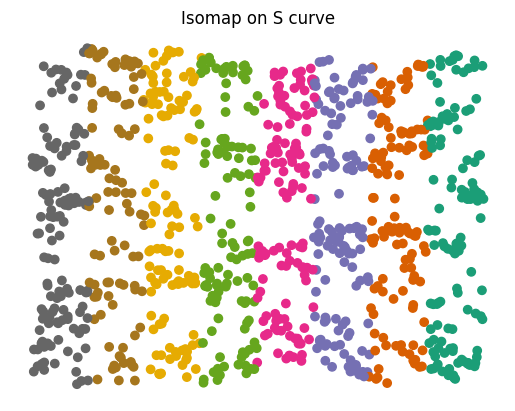

In [ ]:
ax = fig.add_subplot(111)
plt.scatter(reduced_matrix[:, 0], reduced_matrix[:, 1], c=color, cmap=plt.cm.Dark2)
plt.title("Isomap on S curve")
plt.axis('off')
plt.show()

**Isomap on the S-Curve**

**What’s happening in the code?**

- We generate a 3D S-shaped curve.
- We compute pairwise distances and keep only the k nearest neighbors.
- We use Dijkstra’s algorithm to find the shortest paths (geodesics).
- We reduce the data to 2D using eigenvectors.

**Visualization:**

The 3D S-curve is "unrolled" into a 2D plane, preserving the structure.

##### As you can see the Isomap was able to capture the underlying 2d manifold in the S curve dataset.

Now of course there is an easier way to do this, using a predefined library Isomap by sklearn in the manifold module. It just requires you to enter the number of neighbours to be considered and the number of components the graph is to be reduced to.


In [ ]:
from sklearn.manifold import Isomap

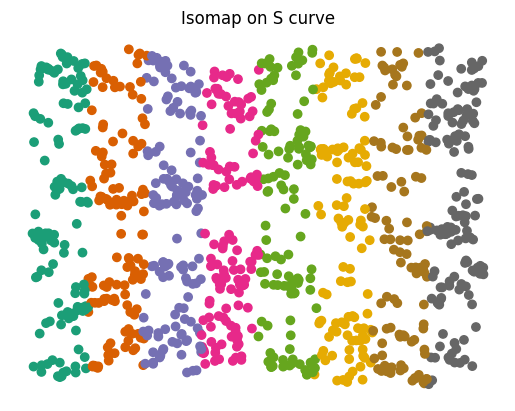

In [ ]:
Y = Isomap(n_neighbors=10, n_components=2).fit_transform(X)

ax = fig.add_subplot(111)
plt.scatter(Y[:, 0], Y[:, 1], c=color, cmap=plt.cm.Dark2)
plt.title("Isomap on S curve")
plt.axis('off')
plt.show()

**Why Use sklearn?**
**Why use sklearn's Isomap?**

- The manual implementation helps you understand the math, but sklearn is optimized and easier to use.
- It’s also more robust for real-world datasets.



---

### Now let us see if Isomap can learn the manifold representation in some more complex datasets

In [ ]:
from sklearn.datasets import fetch_lfw_people
faces = fetch_lfw_people(min_faces_per_person=200)
faces.data.shape

/usr/local/lib/python3.12/dist-packages/sklearn/datasets/_base.py:1519: UserWarning: Retry downloading from url: https://ndownloader.figshare.com/files/5976012
  warnings.warn(f"Retry downloading from url: {remote.url}")


HTTPError: HTTP Error 403: Forbidden

We loaded 766 images, each having 2914 pixels. Let us visualize our dataset before reducing the dimension

In [ ]:
fig, ax = plt.subplots(4, 8, subplot_kw=dict(xticks=[], yticks=[]))
for i, axi in enumerate(ax.flat):
    axi.imshow(faces.images[i], cmap='gray')

**Why Faces?**
**Why use Isomap on faces? **

- Faces are high-dimensional (2914 pixels), but the meaningful variations (e.g., orientation, lighting) lie on a lower-dimensional manifold.
- Isomap reveals these hidden structures.

Our data is 2914 dimensional and our goal is to learn a low dimensional manifold from it. We first apply PCA (which we learn in Lab 2) and see if PCA is able to reduce it to lower dimensions while preserving much of the variance.

In [ ]:
from sklearn.decomposition import PCA as RandomizedPCA
model = RandomizedPCA(100).fit(faces.data)
plt.plot(np.cumsum(model.explained_variance_ratio_))
plt.xlabel('n components')
plt.ylabel('cumulative variance')
plt.plot(range(100), 0.9*np.ones(100))

Let us now try to apply Isomap to this dataset and see if it is able to learn the representation effectively.

In [ ]:
model = Isomap(n_components=2, n_neighbors = 5)
proj = model.fit_transform(faces.data)
proj.shape

We have reduced the dataset from 2914 dimensions to just 2 dimensions. Let us now visualize the result to be able to better understand the latent representation learnt by Isomap

In [ ]:
from matplotlib import offsetbox

def plot_components(data, model, images=None, ax=None, thumb_frac=0.05, cmap='gray'):

    ax = ax or plt.gca()
    proj = model.fit_transform(data)
    ax.plot(proj[:, 0], proj[:, 1], '.k')

    if images is not None:
        min_dist_2 = (thumb_frac * max(proj.max(0) - proj.min(0))) ** 2
        shown_images = np.array([2 * proj.max(0)])
        for i in range(data.shape[0]):
            dist = np.sum((proj[i] - shown_images) ** 2, 1)
            if np.min(dist) < min_dist_2:
                # don't show points that are too close
                continue
            shown_images = np.vstack([shown_images, proj[i]])
            imagebox = offsetbox.AnnotationBbox(
                offsetbox.OffsetImage(images[i], cmap=cmap),
                                      proj[i])
            ax.add_artist(imagebox)

In [ ]:
fig, ax = plt.subplots(figsize=(10, 10))
plot_components(faces.data,
                model=Isomap(n_components=2, n_neighbors = 5),
                images=faces.images[:, ::2, ::2])
plt.xlabel("Face Orientation")
plt.ylabel("Image Darkness")

**PCA vs. Isomap on Faces**

**Observation:**

- PCA needs 70+ dimensions to explain 90% of the variance, implying that PCA is failing to learn the underlying manifold effectively.
- Isomap reduces the data to 2D while preserving meaningful structure (orientation and darkness).

**Interpreting the Face Plot**

**Observation:**

- The 2D plot shows faces arranged by orientation (left to right) and darkness (bottom to top).
- This means Isomap discovered two key features without being told what to look for!

**Example:**

If you sort photos of a person’s face from bright to dark and left-profile to right-profile, you’re doing what Isomap does automatically.



**You are motivated to play around with the number of neighbors and check if the following holds true across neighbourhoods!**

---


# Exercises!!

1. How do you think would the number of neighbors effect the Isomap algorithm? What happens when the number of neighbors considered is very large? What happens when it is very low?

2. When is the ISOMAP algorithm superior to PCA?

3. Search up another manifold learning methods other than ISOMAP? If there are any, whats the key difference ?

4. Suggest ways to deal with missing data in manifold learning.


---

# Answers to Exercies

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.manifold import Isomap
from sklearn.decomposition import PCA

# Generate the S-curve dataset (same as the lab)
n_points = 1000
X, color = datasets.make_s_curve(n_points, random_state=0)

print('Dataset shape:', X.shape)
print('Setup complete!')

Dataset shape: (1000, 3)
Setup complete!


--
## Exercise 1
### Question:
> *How do you think would the number of neighbors affect the Isomap algorithm? What happens when the number of neighbors considered is very large? What happens when it is very low?*

### Answer:

The number of neighbors (`n_neighbors`) is the **most critical hyperparameter** in Isomap. It controls how the adjacency graph is built, which directly affects the quality of geodesic distance estimates.

| Scenario | Effect |
|---|---|
| **k too small** (e.g., k=2) | The graph becomes fragmented — some points are disconnected (geodesic distance = ∞). The manifold is not fully captured. Result: poor or broken embeddings. |
| **k too large** (e.g., k=500) | Neighbors span across the manifold, creating "shortcut" edges that don't follow the true surface. Geodesic distances become wrong. The embedding collapses and loses local structure — behaves more like PCA. |
| **k just right** (e.g., k=5–20) | Neighbors are close enough to follow the local surface, giving accurate geodesic distances and a faithful low-dimensional embedding. |

**Rule of thumb:** Start with k in the range 5–20 and tune by visual inspection or a downstream metric.

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_isomap.py:384: UserWarning: The number of connected components of the neighbors graph is 67 > 1. Completing the graph to fit Isomap might be slow. Increase the number of neighbors to avoid this issue.
  self._fit_transform(X)
/usr/local/lib/python3.12/dist-packages/scipy/sparse/_index.py:168: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])
/usr/local/lib/python3.12/dist-packages/scipy/sparse/_index.py:168: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])
/usr/local/lib/python3.12/dist-packages/scipy/sparse/_index.py:168: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])
/usr/local/lib/python3.12/dist-p

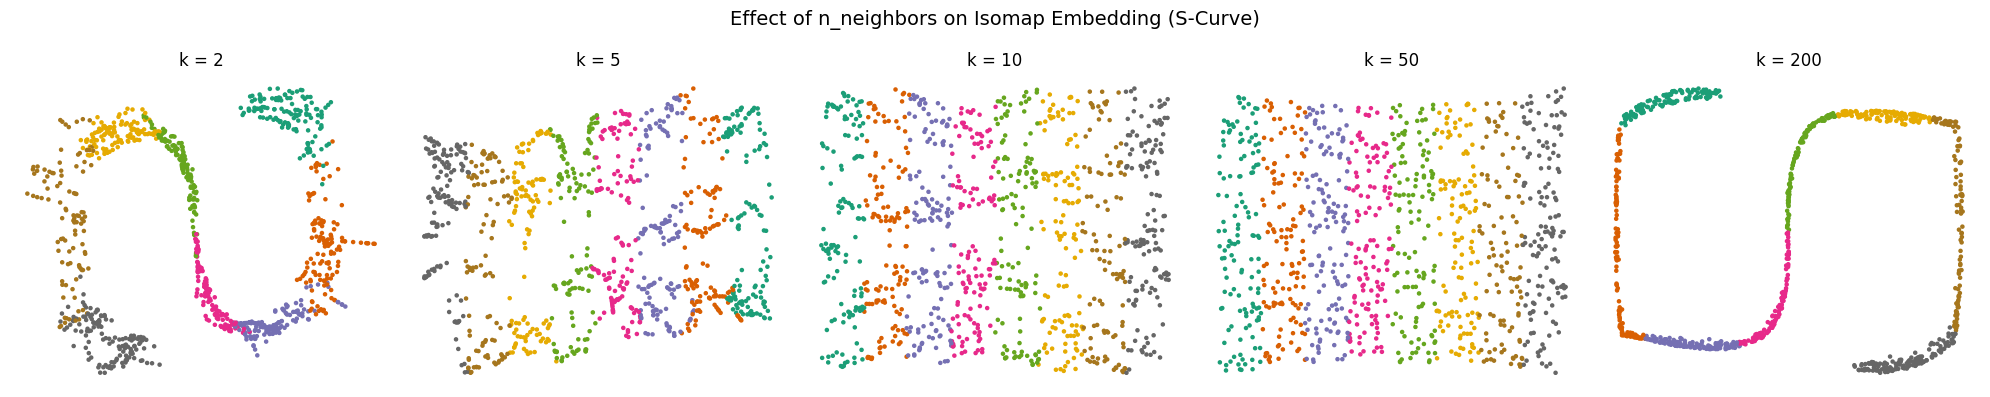


Observations:
  k=2  : May fail or produce a fragmented, broken embedding
  k=5  : Good unrolling of the S-curve, preserving local structure
  k=10 : Clean, faithful 2D representation of the manifold
  k=50 : Starts to collapse — long-range connections distort the shape
  k=200: Very distorted — behaves increasingly like PCA (loses non-linearity)


In [6]:
# Demonstration: Effect of n_neighbors on Isomap embedding of S-curve

neighbor_values = [2, 5, 10, 50, 200]

fig, axes = plt.subplots(1, len(neighbor_values), figsize=(20, 4))
fig.suptitle('Effect of n_neighbors on Isomap Embedding (S-Curve)', fontsize=14)

for ax, k in zip(axes, neighbor_values):
    try:
        model = Isomap(n_neighbors=k, n_components=2)
        Y = model.fit_transform(X)
        ax.scatter(Y[:, 0], Y[:, 1], c=color, cmap=plt.cm.Dark2, s=5)
        ax.set_title(f'k = {k}', fontsize=12)
    except Exception as e:
        ax.set_title(f'k = {k}\n(Error: {str(e)[:30]})', fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()

print()
print('Observations:')
print('  k=2  : May fail or produce a fragmented, broken embedding')
print('  k=5  : Good unrolling of the S-curve, preserving local structure')
print('  k=10 : Clean, faithful 2D representation of the manifold')
print('  k=50 : Starts to collapse — long-range connections distort the shape')
print('  k=200: Very distorted — behaves increasingly like PCA (loses non-linearity)')

---
## Exercise 2
### Question:
> *When is the ISOMAP algorithm superior to PCA?*

### Answer:

Isomap is superior to PCA when the data lies on a **curved (non-linear) low-dimensional manifold** embedded in a high-dimensional space.

#### PCA Limitations
- PCA finds directions of **maximum linear variance**.
- If the true structure of the data is non-linear (e.g., a rolled sheet of paper), PCA cannot "unroll" it correctly.
- PCA preserves **Euclidean (straight-line) distances**, which are misleading when data is curved.

#### When Isomap Wins
| Situation | PCA Result | Isomap Result |
|---|---|---|
| Data lies on a curved surface (e.g., S-curve, Swiss Roll) | Fails to unroll; folds the manifold | Successfully unrolls the manifold |
| Faces varying in orientation/lighting | Needs many components (>70 for 90% variance) | 2 components capture key variation (orientation, darkness) |
| Handwritten digits | Components are not interpretable | Components correspond to stroke angle, curvature, etc. |

#### The Key Difference
Isomap uses **geodesic distances** (shortest path along the data surface), while PCA uses **Euclidean distances** (straight-line, ignoring surface shape). Geodesic distances respect the true geometry of the manifold.

**Summary:** Use Isomap when you suspect the data has a non-linear structure that PCA cannot capture.

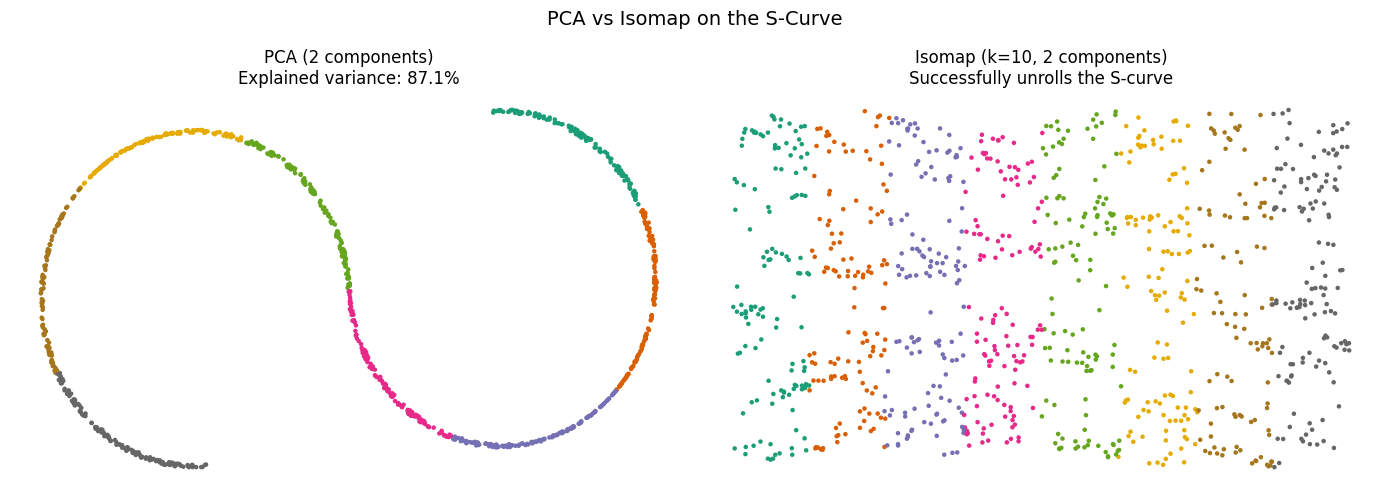


PCA projects onto a flat plane — the two "wings" of the S overlap.
Isomap respects the curved surface and cleanly separates the two wings.


In [7]:
# Demonstration: PCA vs Isomap on the S-curve

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('PCA vs Isomap on the S-Curve', fontsize=14)

# PCA
pca = PCA(n_components=2)
Y_pca = pca.fit_transform(X)
axes[0].scatter(Y_pca[:, 0], Y_pca[:, 1], c=color, cmap=plt.cm.Dark2, s=5)
axes[0].set_title(f'PCA (2 components)\nExplained variance: {pca.explained_variance_ratio_.sum():.1%}',
                  fontsize=12)
axes[0].axis('off')

# Isomap
isomap = Isomap(n_neighbors=10, n_components=2)
Y_iso = isomap.fit_transform(X)
axes[1].scatter(Y_iso[:, 0], Y_iso[:, 1], c=color, cmap=plt.cm.Dark2, s=5)
axes[1].set_title('Isomap (k=10, 2 components)\nSuccessfully unrolls the S-curve', fontsize=12)
axes[1].axis('off')

plt.tight_layout()
plt.show()

print()
print('PCA projects onto a flat plane — the two "wings" of the S overlap.')
print('Isomap respects the curved surface and cleanly separates the two wings.')

---
## Exercise 3
### Question:
> *Search up another manifold learning method other than ISOMAP. If there are any, what's the key difference?*

### Answer:

Yes! There are several well-known manifold learning methods. Here are the most important ones:

#### 1. **LLE (Locally Linear Embedding)**
- Each point is approximated as a **linear combination of its neighbors**.
- The embedding preserves those linear relationships.
- **Key difference from Isomap:** LLE only cares about local linear structure — it does NOT compute global geodesic distances at all.
- **When to use:** When local geometry is more important than global distances.

#### 2. **t-SNE (t-Distributed Stochastic Neighbor Embedding)**
- Converts pairwise distances into **probabilities** of being neighbors.
- Minimizes the divergence between high-dimensional and low-dimensional neighbor distributions.
- **Key difference from Isomap:** t-SNE is extremely good at **visualizing clusters** but does NOT preserve global geometry. Distances between clusters in t-SNE plots are not meaningful.
- **When to use:** Visualizing high-dimensional data when you care about cluster structure (e.g., scRNA-seq, word embeddings).

#### 3. **UMAP (Uniform Manifold Approximation and Projection)**
- Builds a **fuzzy topological graph** and minimizes cross-entropy between high and low-dimensional versions.
- **Key difference from Isomap:** Faster than both Isomap and t-SNE; better at preserving both local AND global structure than t-SNE.
- **When to use:** Large datasets where t-SNE is too slow, or when you need to project new points onto an existing embedding.

#### Summary Table

| Method | Preserves Local Structure | Preserves Global Structure | Speed | New Point Projection |
|---|---|---|---|---|
| **PCA** | ✗ (linear only) | ✓ | Very fast | ✓ |
| **Isomap** | ✓ | ✓ (geodesic) | Slow | ✗ |
| **LLE** | ✓ | ✗ | Medium | ✗ |
| **t-SNE** | ✓ (excellent) | ✗ | Slow | ✗ |
| **UMAP** | ✓ | ✓ (better than t-SNE) | Fast | ✓ |

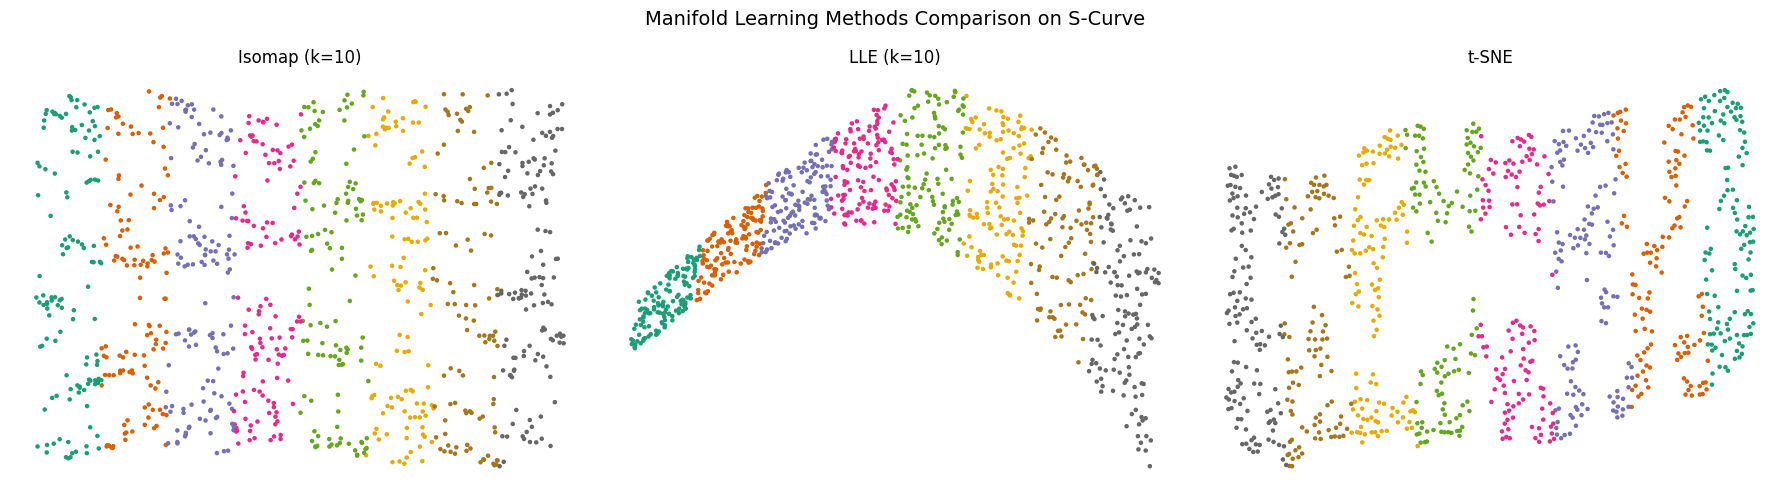


All three methods successfully unroll the S-curve.
Key observation: Isomap preserves global distances best.
t-SNE may rotate or scale the result differently each run.


In [8]:
# Demonstration: Comparing Isomap, LLE, and t-SNE on the S-curve

from sklearn.manifold import LocallyLinearEmbedding, TSNE

methods = {
    'Isomap (k=10)': Isomap(n_neighbors=10, n_components=2),
    'LLE (k=10)':    LocallyLinearEmbedding(n_neighbors=10, n_components=2, method='standard'),
    't-SNE':         TSNE(n_components=2, random_state=42, perplexity=30),
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Manifold Learning Methods Comparison on S-Curve', fontsize=14)

for ax, (name, model) in zip(axes, methods.items()):
    Y = model.fit_transform(X)
    ax.scatter(Y[:, 0], Y[:, 1], c=color, cmap=plt.cm.Dark2, s=5)
    ax.set_title(name, fontsize=12)
    ax.axis('off')

plt.tight_layout()
plt.show()

print()
print('All three methods successfully unroll the S-curve.')
print('Key observation: Isomap preserves global distances best.')
print('t-SNE may rotate or scale the result differently each run.')

---
## Exercise 4
### Question:
> *Suggest ways to deal with missing data in manifold learning.*

### Answer:

Missing data is a significant challenge in manifold learning because **methods like Isomap require complete pairwise distances** to build the neighborhood graph. Unlike PCA (which has well-studied iterative imputation approaches), there is no single standard solution. Here are the main strategies:

---

### Strategy 1: Imputation Before Embedding (Simplest)

Fill in missing values **before** running manifold learning.

| Method | When to Use |
|---|---|
| **Mean/Median imputation** | Quick fix; OK for small fraction of missing data |
| **KNN imputation** | Fills each missing value using the k nearest complete neighbors |
| **Iterative imputation (MICE)** | Models each feature with missing values as a function of others; most accurate |

**Limitation:** Imputation can distort the manifold if data is not missing at random (MAR).

---

### Strategy 2: Use Distances That Handle Missing Data

When computing pairwise distances for the graph, **ignore missing dimensions** and normalize:

$$d(x_i, x_j) = \sqrt{\frac{D}{|O_{ij}|} \sum_{k \in O_{ij}} (x_{ik} - x_{jk})^2}$$

where $O_{ij}$ is the set of dimensions observed in both $x_i$ and $x_j$, and $D$ is total dimensions. This scales the distance to account for the missing ones.

---

### Strategy 3: Probabilistic / Bayesian Manifold Learning

Methods like **GPLVM (Gaussian Process Latent Variable Model)** explicitly model the manifold as a probabilistic process, which naturally handles missing data by marginalizing over the unknown values.

- **Advantage:** Principled uncertainty handling.
- **Disadvantage:** Much more computationally expensive.

---

### Strategy 4: Out-of-Sample Extension After Imputation

1. Impute missing values (e.g., with KNN imputation).
2. Train Isomap/UMAP on the complete imputed dataset.
3. For future points with missing values, re-impute and use the trained model's out-of-sample extension to embed them.

Note: Isomap itself does not have an out-of-sample extension, but UMAP does.

---

### Practical Recommendation

| Missing Data % | Recommended Approach |
|---|---|
| < 5% | Simple mean/median imputation |
| 5–20% | KNN imputation |
| 20–40% | Iterative imputation (MICE) or UMAP (more robust) |
| > 40% | Reconsider whether manifold learning is appropriate; use probabilistic models |

---
**Bottom line:** Unlike PCA, which handles missing data gracefully through iterative SVD, manifold learning requires extra care. Always try to understand *why* data is missing before choosing an imputation strategy.

Original data shape  : (1000, 3)
Missing values count : 294 out of 3000 (9.8%)


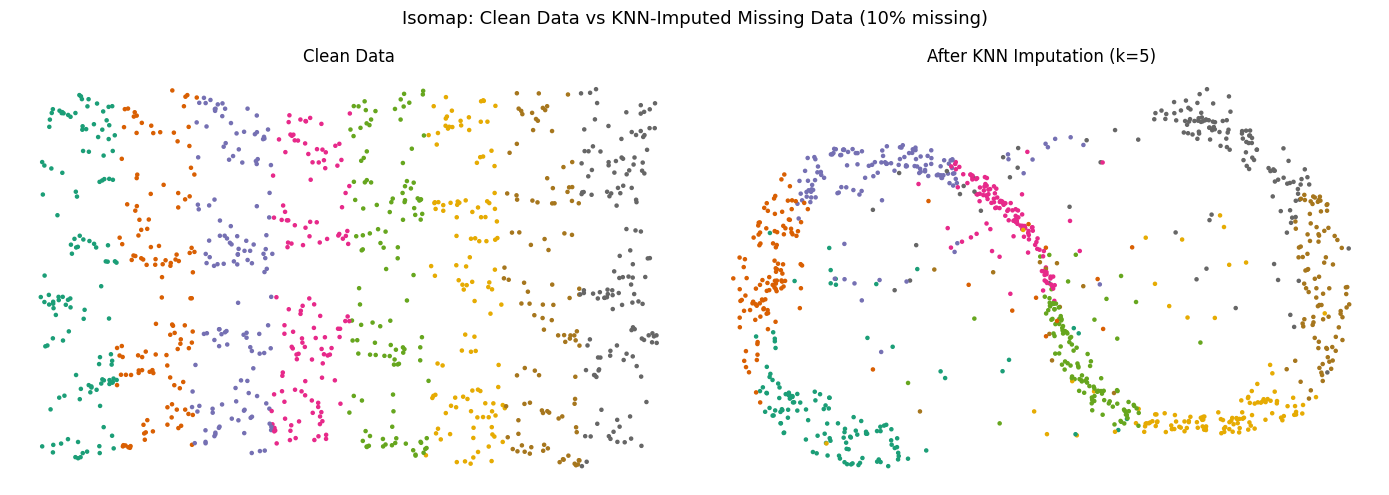


Observation: KNN imputation largely preserves the manifold structure,
but subtle distortions appear compared to the clean embedding.
With more missing data (>30%), the distortion becomes significant.


In [9]:
# Demonstration: KNN Imputation before Isomap

from sklearn.impute import KNNImputer

# Introduce 10% missing data into the S-curve
rng = np.random.default_rng(seed=42)
X_missing = X.copy().astype(float)
mask = rng.random(X_missing.shape) < 0.10   # 10% of values become NaN
X_missing[mask] = np.nan

print(f'Original data shape  : {X.shape}')
print(f'Missing values count : {np.isnan(X_missing).sum()} out of {X_missing.size} ({np.isnan(X_missing).mean():.1%})')

# --- Strategy: KNN Imputation ---
imputer = KNNImputer(n_neighbors=5)
X_imputed = imputer.fit_transform(X_missing)

# Run Isomap on both clean and imputed data
model = Isomap(n_neighbors=10, n_components=2)

Y_clean   = model.fit_transform(X)
Y_imputed = model.fit_transform(X_imputed)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Isomap: Clean Data vs KNN-Imputed Missing Data (10% missing)', fontsize=13)

axes[0].scatter(Y_clean[:, 0],   Y_clean[:, 1],   c=color, cmap=plt.cm.Dark2, s=5)
axes[0].set_title('Clean Data', fontsize=12)
axes[0].axis('off')

axes[1].scatter(Y_imputed[:, 0], Y_imputed[:, 1], c=color, cmap=plt.cm.Dark2, s=5)
axes[1].set_title('After KNN Imputation (k=5)', fontsize=12)
axes[1].axis('off')

plt.tight_layout()
plt.show()

print()
print('Observation: KNN imputation largely preserves the manifold structure,')
print('but subtle distortions appear compared to the clean embedding.')
print('With more missing data (>30%), the distortion becomes significant.')

**Challenges of Manifold Learning**

**Key Issues:**

- Noisy data can create "shortcuts" and distort the manifold.
- Choosing k (number of neighbors) is tricky. Too small → fragmented manifold; too large → loses local structure.
- Missing data is harder to handle than in PCA.

**Analogy:**

- If your GPS has bad signal (noisy data), it might suggest a wrong route.
- If you only ask 2 people for directions (k=2), you might miss the best path.
- If you ask 100 (k=100), you’ll get confused!


## Conclusion:
In practice manifold learning techniques tend to be finicky enough that they are rarely used for anything more than simple qualitative visualization of high-dimensional data.

The following are some of the particular challenges of manifold learning, which all contrast poorly with PCA:

1) In manifold learning, there is no good framework for handling missing data. In contrast, there are straightforward iterative approaches for missing data in PCA.

2) In manifold learning, the presence of noise in the data can "short-circuit" the manifold and drastically change the embedding. In contrast, PCA naturally filters noise from the most important components.

3) The manifold embedding result is generally highly dependent on the number of neighbors chosen, and there is generally no solid quantitative way to choose an optimal number of neighbors. In contrast, PCA does not involve such a choice.

4) In manifold learning, the globally optimal number of output dimensions is difficult to determine. In contrast, PCA lets you find the output dimension based on the explained variance.

5) In manifold learning, the meaning of the embedded dimensions is not always clear. In PCA, the principal components have a very clear meaning.

6) In manifold learning the computational expense of manifold methods scales as O[N^2] or O[N^3]. For PCA, there exist randomized approaches that are generally much faster (though see the megaman package for some more scalable implementations of manifold learning).

Therefore with all that on the table, the only clear advantage of manifold learning methods over PCA is their ability to preserve nonlinear relationships in the data; for that reason I tend to explore data with manifold methods only after first exploring them with PCA.



**When to Use Manifold Learning?**

**Use cases:**

- Visualizing high-dimensional data (e.g., genomics, images).
- Preprocessing for clustering or classification.

**Limitations:**

- Not scalable to millions of points.
- Mostly used for exploration, not production.



| Feature               | PCA                          | Isomap                      |
|-----------------------|------------------------------|-----------------------------|
| **Assumption**        | Linear structure             | Non-linear manifold         |
| **Distance Used**     | Euclidean                    | Geodesic                    |
| **Speed**             | Fast                         | Slow (O[N²] or O[N³])        |
| **Handles Noise?**    | Yes                          | Sensitive to noise          |
| **Missing Data?**     | Easy (iterative imputation)  | Hard                        |
| **Output Dimensions** | Clear (explained variance)   | Ambiguous                   |
| **Scalability**       | High (randomized methods)    | Low (computationally heavy) |
| **Use Case**          | General-purpose              | Non-linear visualization    |



---


### Some interesting references:

1) https://axon.cs.byu.edu/Dan/678/miscellaneous/Manifold.example.pdf

2) http://vision.cse.psu.edu/seminars/talks/PRML/David_NDR_lecture.pdf


---

